In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.set_index('Fecha')

print(df.shape)
print(df.head())

(4869, 15)
            precio_bolsa  aportes_energia_gwh  vertimientos_energia_gwh  \
Fecha                                                                     
2013-01-01      161.8653          124884800.0                      0.00   
2013-01-02      193.6470          133792600.0                 278217.60   
2013-01-03      184.4642          122927200.0                 215713.92   
2013-01-04      188.2384          108007000.0                      0.00   
2013-01-05      178.6095          111063800.0                      0.00   

            gen_cogenerador  gen_eolica  gen_hidraulica  gen_solar  \
Fecha                                                                
2013-01-01        491244.73   182644.13    8.746490e+07        0.0   
2013-01-02        479816.69   178536.06    1.008231e+08        0.0   
2013-01-03        481465.91   185739.95    1.118072e+08        0.0   
2013-01-04        532811.47   207817.63    1.155799e+08        0.0   
2013-01-05        528232.27   238753.31    

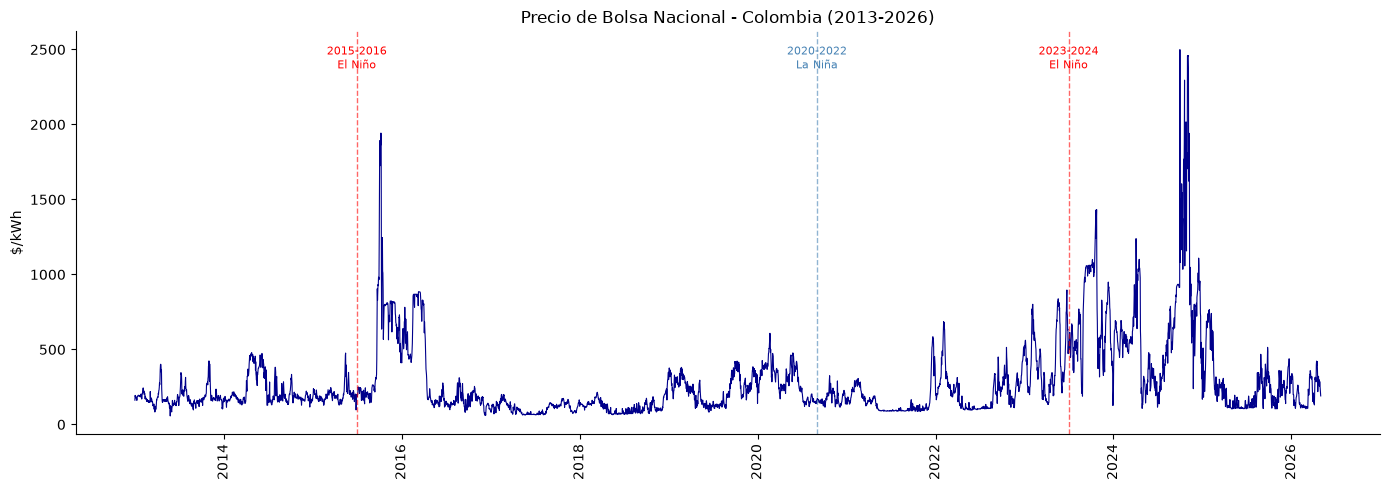

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['precio_bolsa'], color='darkblue', linewidth=0.8)

eventos = {
    '2015-2016\nEl Niño': ('2015-07-01', 'red'),
    '2023-2024\nEl Niño': ('2023-07-01', 'red'),
    '2020-2022\nLa Niña': ('2020-09-01', 'steelblue'),
}

for label, (fecha, color) in eventos.items():
    ax.axvline(pd.to_datetime(fecha), color=color, linestyle='--', alpha=0.6, linewidth=1)
    ax.text(pd.to_datetime(fecha), df['precio_bolsa'].max() * 0.95, label,
            fontsize=8, color=color, ha='center')

ax.set_ylabel('$/kWh')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=90)
ax.set_title('Precio de Bolsa Nacional - Colombia (2013-2026)')
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
stats_anuales = df.groupby(df.index.year)['precio_bolsa'].agg([
    'count', 'mean', 'std', 'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).round(2)

stats_anuales.columns = ['n', 'media', 'std', 'min', 'max', 'p25', 'p75']
stats_anuales['cv'] = (stats_anuales['std'] / stats_anuales['media']).round(3)
stats_anuales.index.name = 'año'
print(stats_anuales)

        n   media     std     min      max     p25     p75     cv
año                                                              
2013  365  180.11   57.39   56.63   423.66  149.47  192.16  0.319
2014  365  228.57   99.63  114.96   478.91  160.81  279.11  0.436
2015  365  382.40  338.77   97.01  1942.71  181.12  564.02  0.886
2016  366  303.17  249.08   61.17   884.37  136.34  443.99  0.822
2017  365  107.55   34.00   62.83   200.08   75.08  133.88  0.316
2018  365  117.75   45.00   64.91   348.04   78.83  139.07  0.382
2019  365  232.05   88.79   81.98   422.51  141.68  299.53  0.383
2020  366  254.38  106.57  114.53   607.74  161.69  343.65  0.419
2021  365  151.35   92.66   86.24   584.95   92.43  174.54  0.612
2022  365  218.29  120.40   94.95   685.50  109.80  277.90  0.552
2023  365  564.13  286.88  126.22  1432.60  335.23  754.18  0.509
2024  366  683.51  444.85  107.14  2498.80  381.80  851.05  0.651
2025  365  245.76  152.95  102.89   765.95  125.03  292.66  0.622
2026  121 

Identificando patrones estacionales por mes

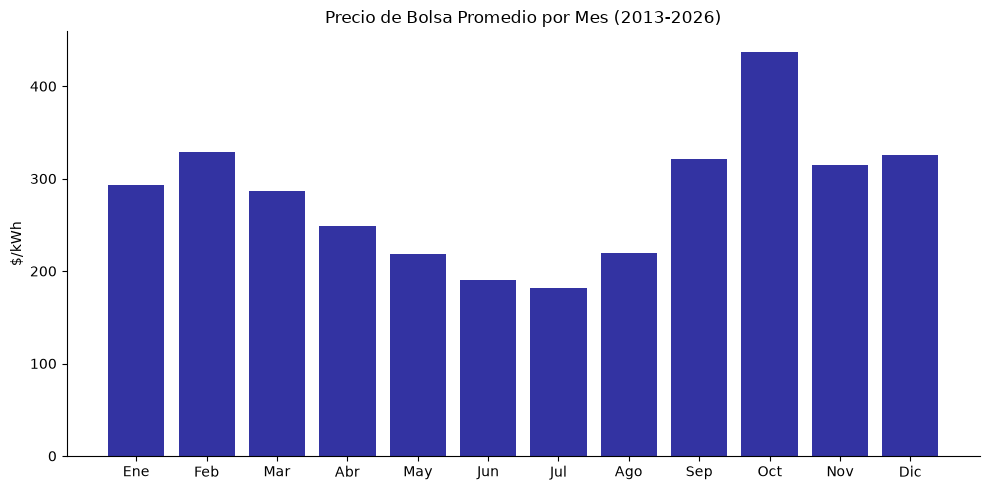

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

estacionalidad = df.groupby(df.index.month)['precio_bolsa'].mean()

ax.bar(meses, estacionalidad.values, color='darkblue', alpha=0.8)
ax.set_ylabel('$/kWh')
ax.set_xlabel('')
ax.set_title('Precio de Bolsa Promedio por Mes (2013-2026)')
sns.despine()
plt.tight_layout()
plt.show()

Descomposicion en tendencia, estacionalidad y residuo

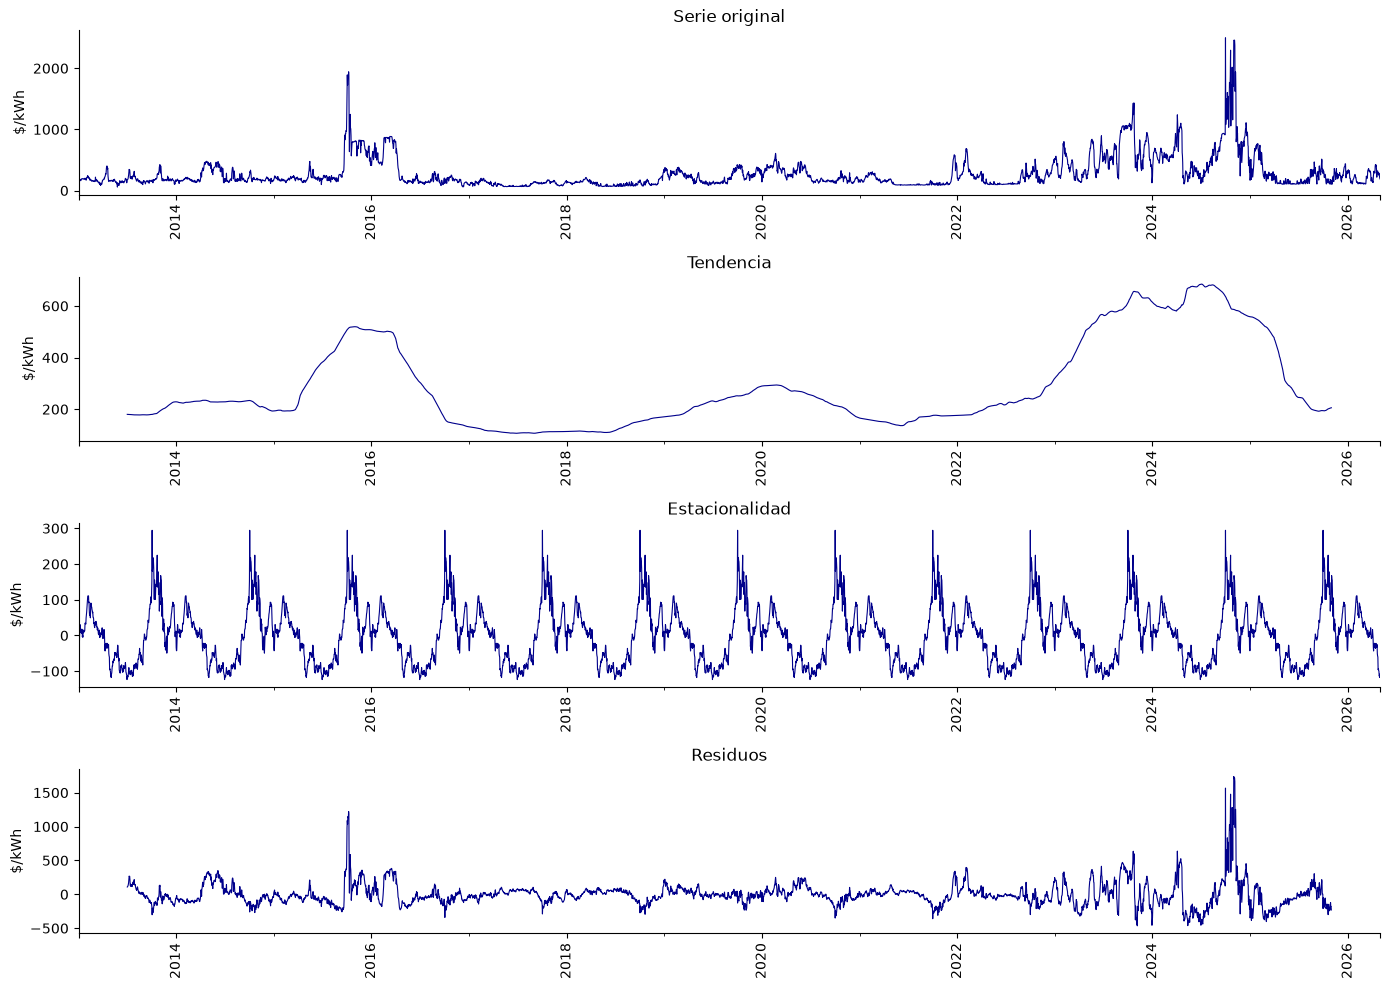

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['precio_bolsa'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomp.observed.plot(ax=axes[0], color='darkblue', linewidth=0.8)
axes[0].set_ylabel('$/kWh')
axes[0].set_title('Serie original')

decomp.trend.plot(ax=axes[1], color='darkblue', linewidth=0.8)
axes[1].set_ylabel('$/kWh')
axes[1].set_title('Tendencia')

decomp.seasonal.plot(ax=axes[2], color='darkblue', linewidth=0.8)
axes[2].set_ylabel('$/kWh')
axes[2].set_title('Estacionalidad')

decomp.resid.plot(ax=axes[3], color='darkblue', linewidth=0.8)
axes[3].set_ylabel('$/kWh')
axes[3].set_title('Residuos')

for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_xlabel('')

sns.despine()
plt.tight_layout()
plt.show()

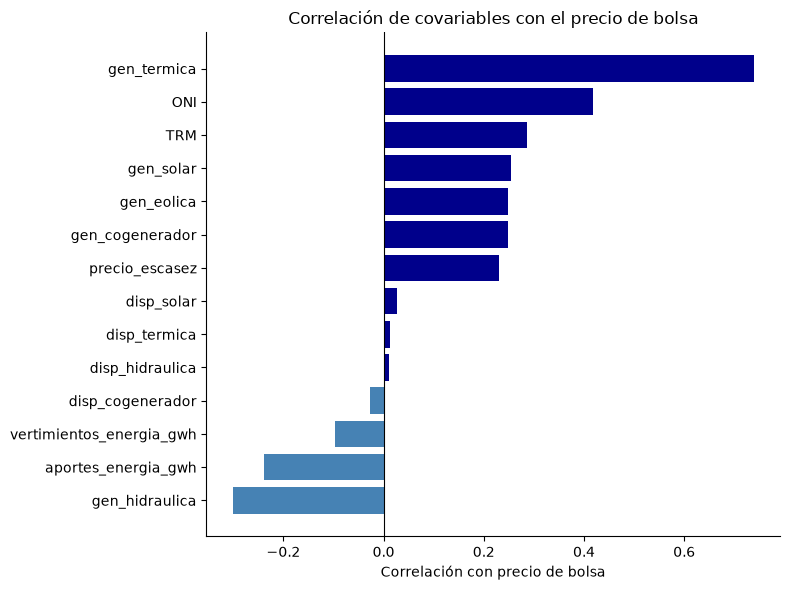

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

colores = ['darkblue' if x > 0 else 'steelblue' for x in corr.values]

ax.barh(corr.index, corr.values, color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación con precio de bolsa')
ax.set_title('Correlación de covariables con el precio de bolsa')
sns.despine()
plt.tight_layout()
plt.show()

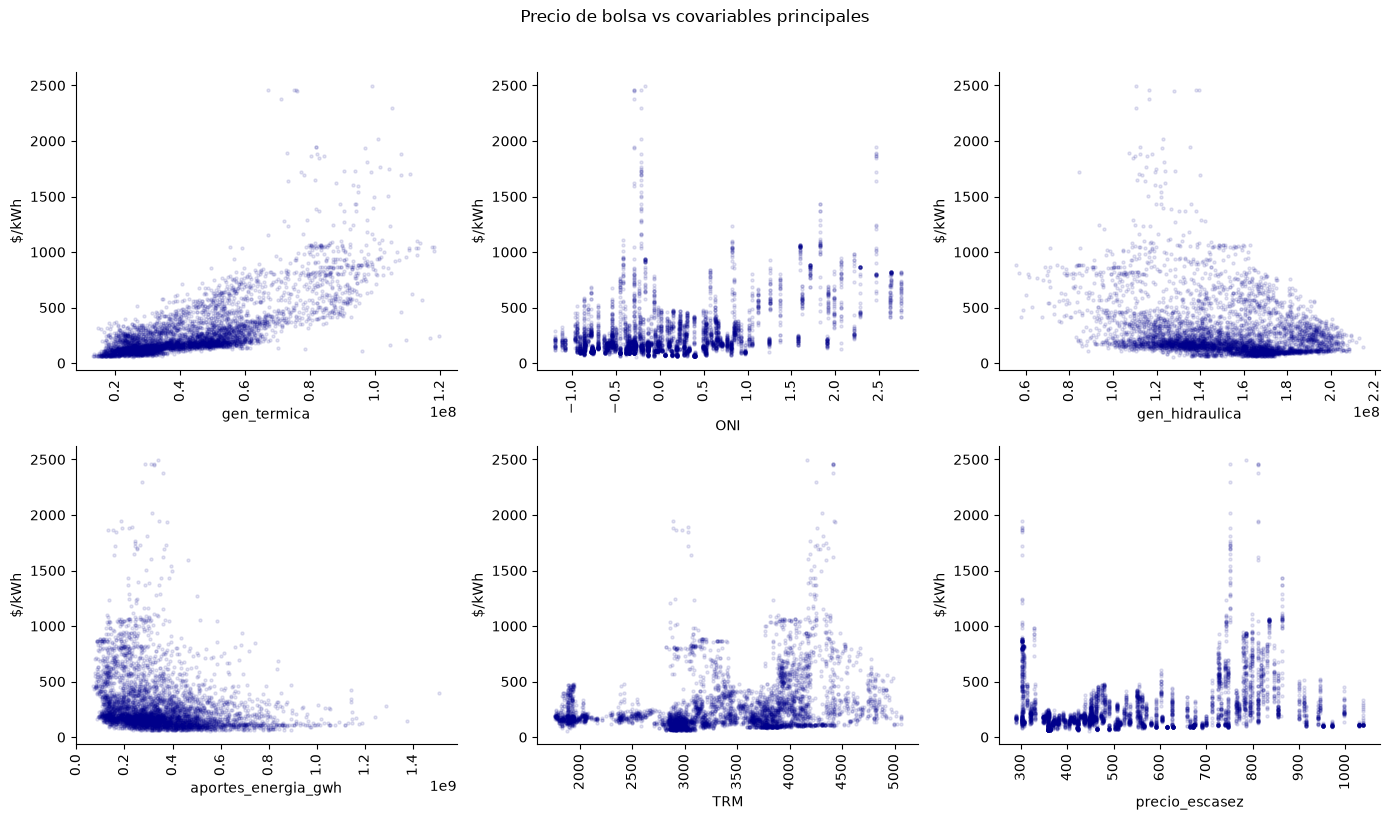

In [14]:
variables_top = ['gen_termica', 'ONI', 'gen_hidraulica', 'aportes_energia_gwh', 'TRM', 'precio_escasez']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(variables_top):
    axes[i].scatter(df[var], df['precio_bolsa'], alpha=0.1, s=5, color='darkblue')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('$/kWh')
    axes[i].tick_params(axis='x', rotation=90)
    sns.despine(ax=axes[i])

plt.suptitle('Precio de bolsa vs covariables principales', y=1.02)
plt.tight_layout()
plt.show()

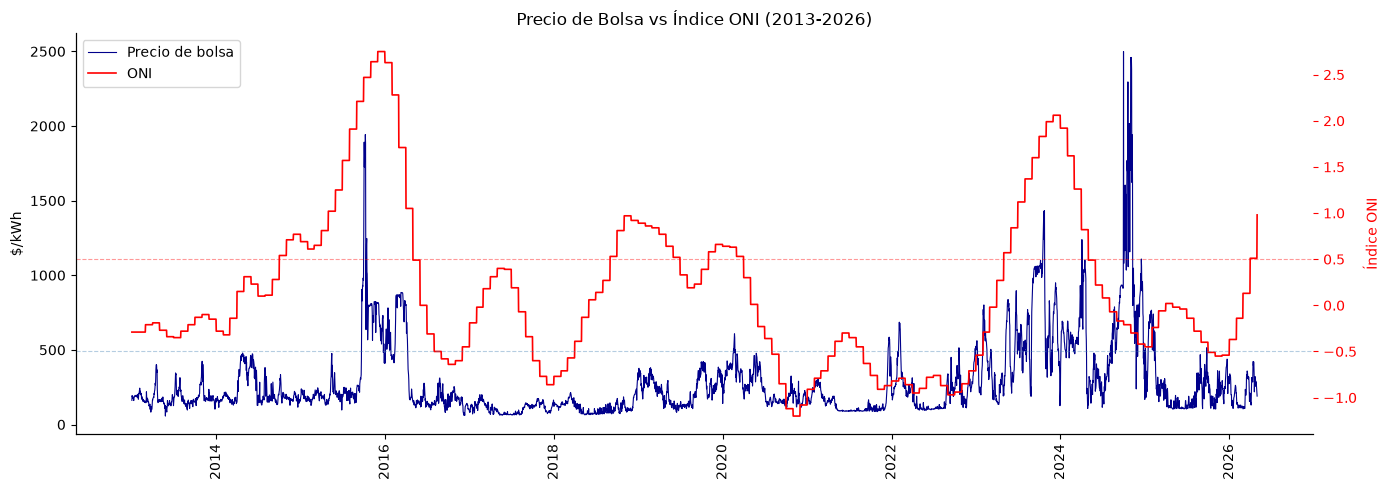

In [15]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax2 = ax1.twinx()

ax1.plot(df.index, df['precio_bolsa'], color='darkblue', linewidth=0.8, label='Precio de bolsa')
ax2.plot(df.index, df['ONI'], color='red', linewidth=1.2, label='ONI')
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
ax2.axhline(-0.5, color='steelblue', linestyle='--', alpha=0.4, linewidth=0.8)

ax1.set_ylabel('$/kWh')
ax2.set_ylabel('Índice ONI', color='red')
ax2.tick_params(axis='y', colors='red')
ax1.tick_params(axis='x', rotation=90)
ax1.set_xlabel('')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Precio de Bolsa vs Índice ONI (2013-2026)')
sns.despine()
plt.tight_layout()
plt.show()

ACF Y PACF del precio de bolsa

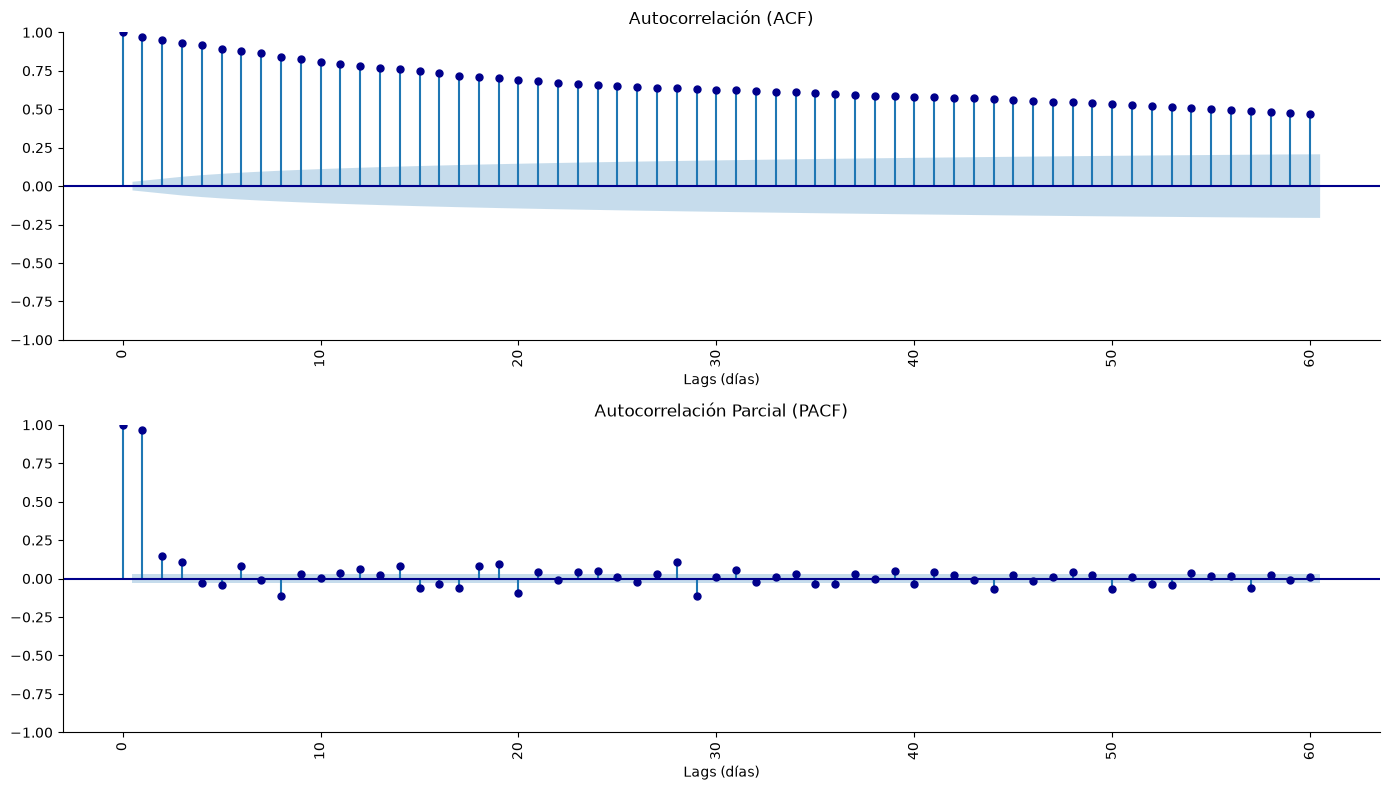

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df['precio_bolsa'], lags=60, ax=axes[0], color='darkblue', title='Autocorrelación (ACF)')
plot_pacf(df['precio_bolsa'], lags=60, ax=axes[1], color='darkblue', title='Autocorrelación Parcial (PACF)')

for ax in axes:
    ax.set_xlabel('Lags (días)')
    ax.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Prueba ADF

In [17]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df['precio_bolsa'])
print(f"Estadístico ADF: {resultado[0]:.4f}")
print(f"p-valor: {resultado[1]:.4f}")
print(f"Valores críticos:")
for key, val in resultado[4].items():
    print(f"  {key}: {val:.4f}")

Estadístico ADF: -4.7399
p-valor: 0.0001
Valores críticos:
  1%: -3.4317
  5%: -2.8621
  10%: -2.5671


Análisis de valores extremos 

In [18]:
q99 = df['precio_bolsa'].quantile(0.99)
q01 = df['precio_bolsa'].quantile(0.01)

extremos = df[df['precio_bolsa'] > q99][['precio_bolsa', 'ONI', 'gen_termica', 'gen_hidraulica']]

print(f"Umbral percentil 99: {q99:.2f} $/kWh")
print(f"Días sobre ese umbral: {len(extremos)}")
print(f"\nDistribución por año:")
print(extremos.groupby(extremos.index.year)['precio_bolsa'].count())

Umbral percentil 99: 1239.67 $/kWh
Días sobre ese umbral: 49

Distribución por año:
Fecha
2015     9
2023     6
2024    34
Name: precio_bolsa, dtype: int64


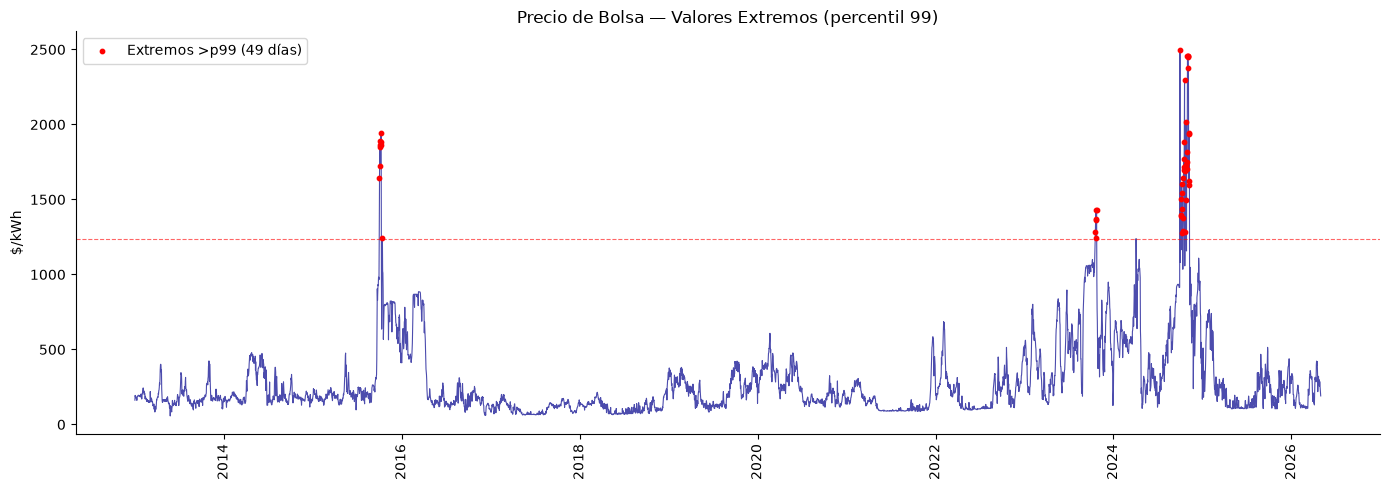

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['precio_bolsa'], color='darkblue', linewidth=0.8, alpha=0.7)
ax.scatter(extremos.index, extremos['precio_bolsa'], color='red', s=10, zorder=5, label=f'Extremos >p99 ({len(extremos)} días)')

ax.axhline(q99, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylabel('$/kWh')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=90)
ax.set_title('Precio de Bolsa — Valores Extremos (percentil 99)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

Comportamiento de las covariables

In [21]:
print("Disponibilidad hidráulica > 1:")
print(df[df['disp_hidraulica'] > 1][['disp_hidraulica']].sort_values('disp_hidraulica', ascending=False).head(10))

print("\nDisponibilidad térmica > 1:")
print(df[df['disp_termica'] > 1][['disp_termica']].sort_values('disp_termica', ascending=False).head(10))

Disponibilidad hidráulica > 1:
            disp_hidraulica
Fecha                      
2024-09-01           334.71

Disponibilidad térmica > 1:
            disp_termica
Fecha                   
2024-09-01    439.471067


In [22]:
df.loc['2024-09-01', 'disp_hidraulica'] = None
df.loc['2024-09-01', 'disp_termica'] = None
df[['disp_hidraulica', 'disp_termica']] = df[['disp_hidraulica', 'disp_termica']].ffill()

print(df.loc['2024-09-01', ['disp_hidraulica', 'disp_termica']])

disp_hidraulica    0.752605
disp_termica       0.735333
Name: 2024-09-01 00:00:00, dtype: float64


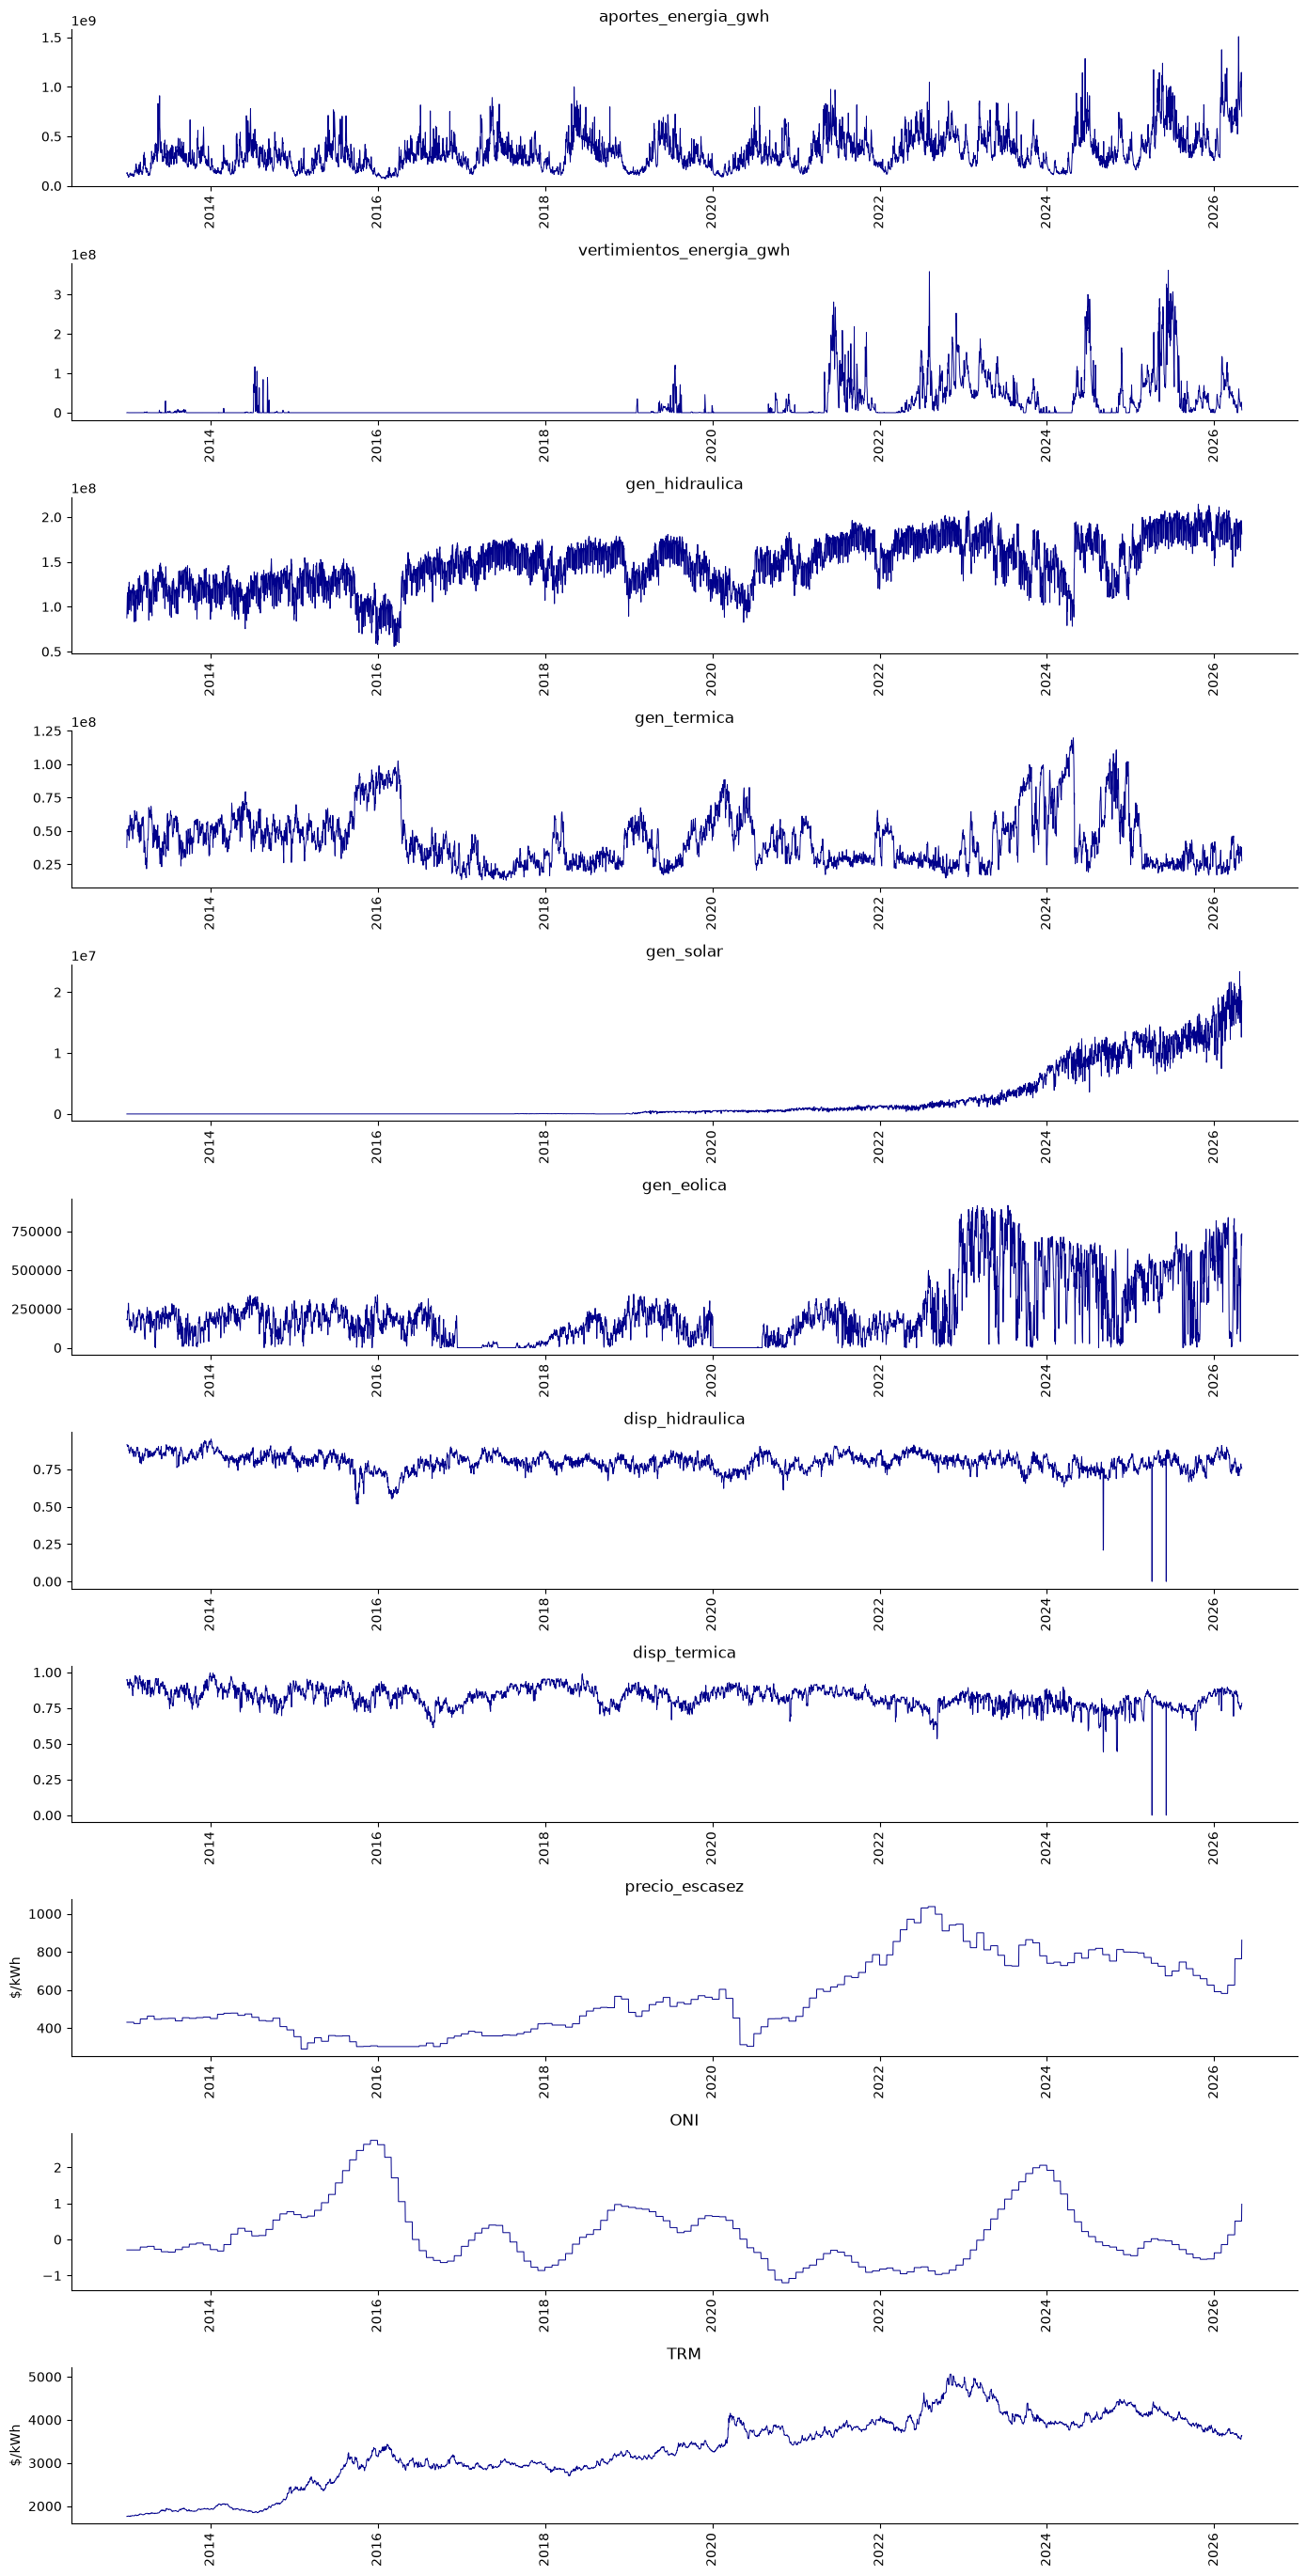

In [23]:
covariables = [
    'aportes_energia_gwh', 'vertimientos_energia_gwh',
    'gen_hidraulica', 'gen_termica', 'gen_solar', 'gen_eolica',
    'disp_hidraulica', 'disp_termica',
    'precio_escasez', 'ONI', 'TRM'
]

fig, axes = plt.subplots(len(covariables), 1, figsize=(14, len(covariables) * 2.5))

for i, var in enumerate(covariables):
    axes[i].plot(df.index, df[var], color='darkblue', linewidth=0.7)
    axes[i].set_ylabel('$/kWh' if 'precio' in var or var == 'TRM' else '')
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=90)
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

In [24]:
df.to_parquet(BASE / 'dataset_consolidado.parquet')
print("Dataset actualizado guardado.")

Dataset actualizado guardado.


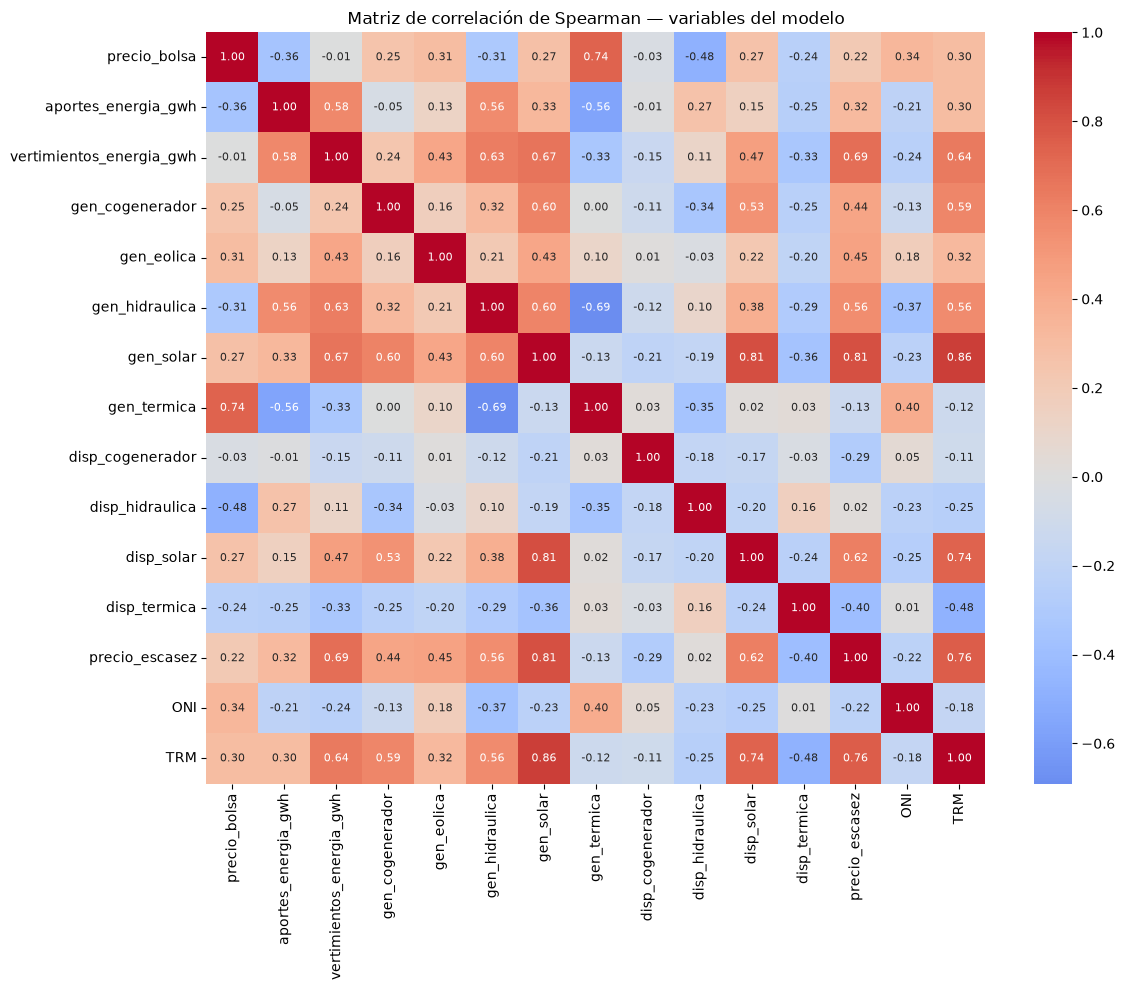

In [26]:
fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = df.corr(method='spearman')

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            ax=ax,
            annot_kws={'size': 8})

ax.set_title('Matriz de correlación de Spearman — variables del modelo')
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()